# 2012 fit random forest and use it for feature selection. 
- one-hot encode data (aka create dummy variables)
- test RF training and test score by max depth
- select RF depth and use it for further steps:
- calculate and save confusion matrix
- calculate feature importances using two approaches: gini impurity and permutation
  - results in two sets of most important features
- refit RF with only a subset of the most important features and display RF score by number of features

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix #plot_confusion_matrix, 
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


In [31]:
#read data and drop columns that would generate too many dummy variables in the one-hot encoding
dat = pd.read_parquet('data/votersurvey_cleaned_noDropNA_2012.parquet')
dat = dat.dropna()
#dat = dat.drop(columns = "inputstate_2016") #creates too many dummy variables


#prepare data
y = dat["presvote16post_2016"]
X = dat.drop(columns = "presvote16post_2016")
#one-hot encode categorical data
X_oh = pd.get_dummies(X, dtype = int)
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)

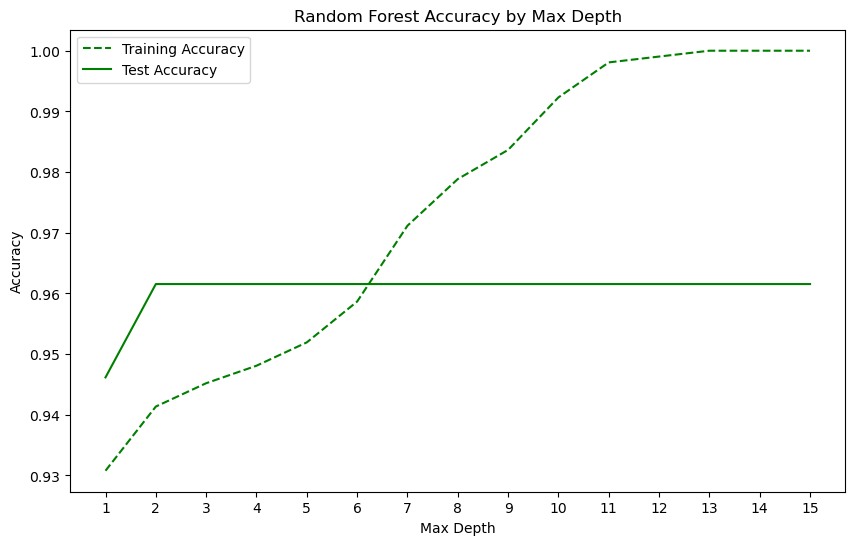

In [32]:
# test RF performance by max depth

# Initialize lists to store results
depths = list(range(1, 16))
train_accuracies = []
test_accuracies = []

# Run Random Forest for each depth
for i in depths:
    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=123,
        max_depth=i,
        #max_features = 20
    )
    rf.fit(X_train_oh, y_train)

    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'max_depth': depths,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['max_depth'], results_df['train_accuracy'], label='Training Accuracy', linestyle = '--', color = 'green')
plt.plot(results_df['max_depth'], results_df['test_accuracy'], label='Test Accuracy', color = 'green')

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by Max Depth')
plt.legend()
plt.grid(False)
plt.xticks(depths)
#save figure
#plt.savefig('results/RF/RF_performance_by_maxdepth_clinton_trump_2012.png')
plt.show()



# Display the DataFrame
#print("\nResults DataFrame:")
#print(results_df)

                 precision    recall  f1-score   support

   Donald Trump       0.98      0.93      0.95       114
Hillary Clinton       0.95      0.99      0.97       146

       accuracy                           0.96       260
      macro avg       0.96      0.96      0.96       260
   weighted avg       0.96      0.96      0.96       260



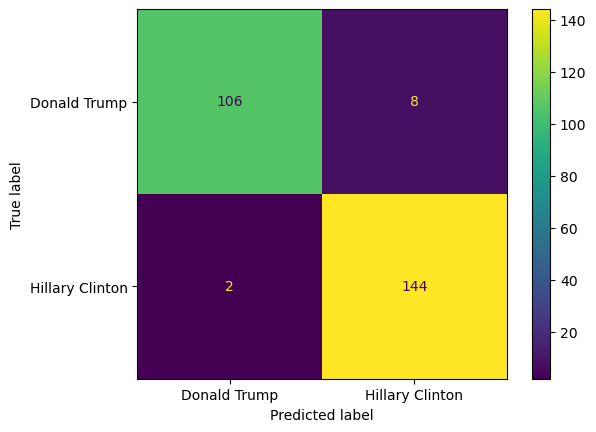

In [33]:
#choose selected maxdepth
selectedmaxdepth = 3 #no significant increase in test accuracy afterwards

# run random forest with prefered depth and create confusion matrix
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
rf.fit(X_train_oh, y_train)

y_pred = rf.predict(X_test_oh)
cmat = confusion_matrix(y_test, y_pred, labels = rf.classes_)
ConfusionMatrixDisplay(cmat, display_labels = rf.classes_).plot()

#save confmat figure
plt.savefig(f'results/RF/RF_confmat_maxdepth{selectedmaxdepth}_2012.png')

#classification report
print(classification_report(y_test, y_pred))

## extract feature importances
based on the random forest with chosen max depth
- method 1: using mean decrease in gini impurities
- method 2: using feature permutation. I believe this is the better approach since we have high-cardinality features

### feature importance using mean decrease in gini impurities

In [34]:
#extract feature importance and regroup by dummy variable
#e. g. sum over the rows "presvote16post_2016_Hillary Clinton" and "presvote16post_2016_Donald Trump"

#this can be used for feature selection


#create df
imp = rf.feature_importances_
imp_names = rf.feature_names_in_
imp_df = pd.DataFrame({"imp" : imp, "imp_names" : imp_names})

# Extract the base name (everything before the last underscore)
imp_df["base_name"] = imp_df["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
imp_df_grouped = imp_df.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
imp_df_grouped = imp_df_grouped.rename(columns = {"imp": "imp_grouped"})

imp_df_grouped.to_csv("data/featureselection_gini_score_2012.csv") 
imp_df_grouped.head(25)

,base_name,imp_grouped
12,cmatch_ging_baseline,0.048013
13,cmatch_romn_baseline,0.043604
193,presvote08_baseline,0.041226
190,post_presvote12_2012,0.039811
260,vote_generic_baseline,0.036162
184,post_house12_2012,0.034913
14,cong2012_2_baseline,0.030519
50,fav_obama_baseline,0.028112
239,univhealthcov_baseline,0.026638
68,ideoobama_baseline,0.024413


In [35]:
#individual feature importances for comparison
imp_df.sort_values("imp", ascending = False).head(25)

,imp,imp_names,base_name
635,0.025689,cmatch_ging_baseline_Barack Obama,cmatch_ging_baseline
631,0.023407,cmatch_romn_baseline_Barack Obama,cmatch_romn_baseline
636,0.022176,cmatch_ging_baseline_Newt Gingrich,cmatch_ging_baseline
5472,0.022157,post_presvote12_2012_Mitt Romney,post_presvote12_2012
307,0.021707,vote_generic_baseline_The Democratic Party can...,vote_generic_baseline
525,0.021691,presvote08_baseline_Barack Obama,presvote08_baseline
632,0.020062,cmatch_romn_baseline_Mitt Romney,cmatch_romn_baseline
5476,0.019831,post_house12_2012_$HouseCand2Name ($HouseCand2...,post_house12_2012
526,0.019443,presvote08_baseline_John McCain,presvote08_baseline
570,0.019046,fav_obama_baseline_Very unfavorable,fav_obama_baseline


### fit random forest using the feature selection based on gini impurity

In [36]:
selectedfeatures_gini = imp_df_grouped['base_name'].head(25)
selectedfeatures_gini.to_csv('data/selectedfeautures_gini_2012.csv')
selectedfeatures_gini

12          cmatch_ging_baseline
13          cmatch_romn_baseline
193          presvote08_baseline
190         post_presvote12_2012
260        vote_generic_baseline
184            post_house12_2012
14           cong2012_2_baseline
50            fav_obama_baseline
239       univhealthcov_baseline
68            ideoobama_baseline
128            obamaapp_baseline
232           taxwealth_baseline
63     healthreformbill_baseline
46            fav_biden_baseline
107           likeobama_baseline
45             fav_bach_baseline
218    selfdescr_ccap_7_baseline
233          teapartsup_baseline
188               post_pid3_2012
40             envpoll2_baseline
42              envwarm_baseline
194              prim12_baseline
55              gaymar2_baseline
158                pid3_baseline
64         healthtaxch3_baseline
Name: base_name, dtype: str

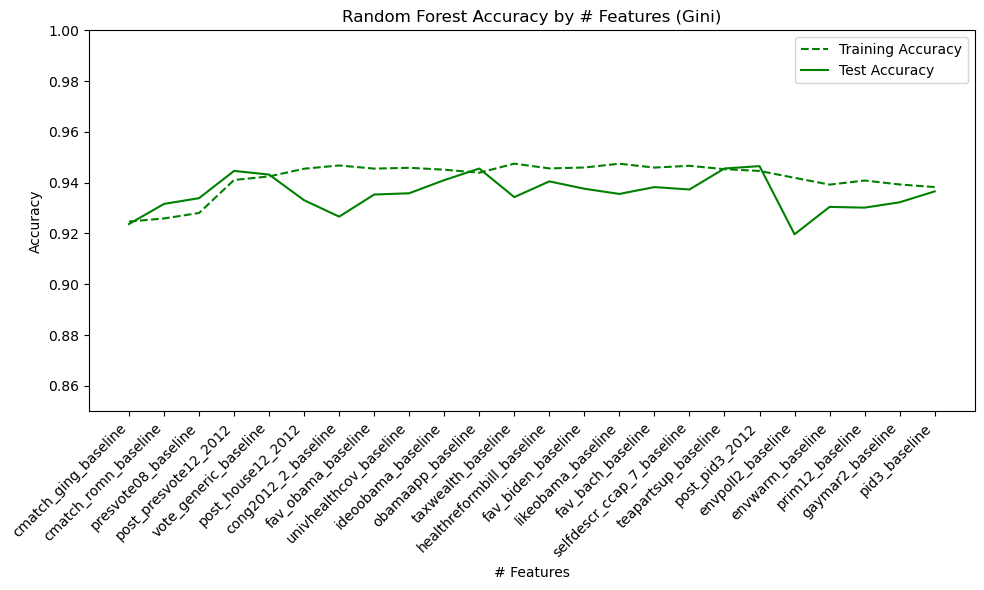

In [37]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 25))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:
    #read inital df each time and drop rows after selecting variables
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA_2012.parquet') 
    featurestokeep = selectedfeatures_gini[0:i].copy()
    featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'train_accuracy': train_accuracies,
    'Feature Names': selectedfeatures_gini[:len(featurecount)],  # Get corresponding feature names
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'], label='Training Accuracy', linestyle = '--', color = 'green')
plt.plot(results_df['# Features'], results_df['test_accuracy'], label='Test Accuracy', color = 'green')
plt.ylim(0.85, 1.0)
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by # Features (Gini)')
plt.legend()
plt.grid(False)

# Set custom x-tick labels
plt.xticks(ticks=featurecount, labels=results_df['Feature Names'], rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to prevent label cutoff


#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_gini_maxdepth_2012{selectedmaxdepth}.png')
plt.show()


    

### feature importance using permutation importance

In [38]:
#feature importance based on permutation importance
#this takes a few minutes to run

from sklearn.inspection import permutation_importance

# run random forest with preferred depth and create confusion matrix
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
rf.fit(X_train_oh, y_train)

result = permutation_importance(
    rf, X_test_oh, y_test, random_state=42, n_jobs=-1
)

In [39]:
#create df
imp = result.importances_mean
imp_names = rf.feature_names_in_
permutation_importances = pd.DataFrame({"imp_names" : imp_names, "imp" : imp})

# Extract the base name (everything before the last underscore)
permutation_importances["base_name"] = permutation_importances["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
permutation_importances_grouped = permutation_importances.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
permutation_importances_grouped = permutation_importances_grouped.rename(columns = {"imp": "imp_grouped"})


permutation_importances_grouped.to_csv("data/featureselection_PM_score_2012.csv") 
#display grouped permutation importances
permutation_importances_grouped.head(25)

,base_name,imp_grouped
23,vote_generic_baseline,4.077010e-03
1,cmatch_romn_baseline,3.850510e-03
0,cmatch_ging_baseline,2.944507e-03
7,fav_obama_baseline,2.491506e-03
12,obamaapp_baseline,1.812005e-03
18,prim12_baseline,1.812005e-03
9,healthreformbill_baseline,1.585504e-03
2,cong2012_2_baseline,9.060023e-04
13,pid3_baseline,6.795017e-04
10,ideoobama_baseline,6.795017e-04


In [40]:
#display individual permutaiton importances
permutation_importances.sort_values('imp', ascending = False).head(25)

,imp_names,imp,base_name
0,cmatch_ging_baseline_Barack Obama,0.003398,cmatch_ging_baseline
21,vote_generic_baseline_The Democratic Party can...,0.003171,vote_generic_baseline
4,cmatch_romn_baseline_Barack Obama,0.002945,cmatch_romn_baseline
39,fav_obama_baseline_Very unfavorable,0.001586,fav_obama_baseline
60,healthreformbill_baseline_Repealed,0.001586,healthreformbill_baseline
98,prim12_baseline_Republican primary or caucus,0.001133,prim12_baseline
33,cong2012_2_baseline_The Democratic Party candi...,0.000906,cong2012_2_baseline
22,vote_generic_baseline_The Republican Party can...,0.000906,vote_generic_baseline
53,obamaapp_baseline_Strongly Disapprove,0.000906,obamaapp_baseline
5,cmatch_romn_baseline_Mitt Romney,0.000906,cmatch_romn_baseline


### fit random forest using the feature selection based on permutation importances

In [58]:
#isolate top 25 features
selectedfeatures_perm = permutation_importances_grouped['base_name'].head(25)
selectedfeatures_perm.to_csv('data/selectedfeautures_permutation_2012.csv')
selectedfeatures_perm

23        vote_generic_baseline
1          cmatch_romn_baseline
0          cmatch_ging_baseline
7            fav_obama_baseline
12            obamaapp_baseline
18              prim12_baseline
9     healthreformbill_baseline
2           cong2012_2_baseline
13                pid3_baseline
10           ideoobama_baseline
11           likeobama_baseline
21          teapartsup_baseline
6            fav_biden_baseline
5             fav_bach_baseline
4              envwarm_baseline
3             envpoll2_baseline
15               post_pid3_2012
14            post_house12_2012
8              gaymar2_baseline
17          presvote08_baseline
20           taxwealth_baseline
19    selfdescr_ccap_7_baseline
22       univhealthcov_baseline
16         post_presvote12_2012
Name: base_name, dtype: str

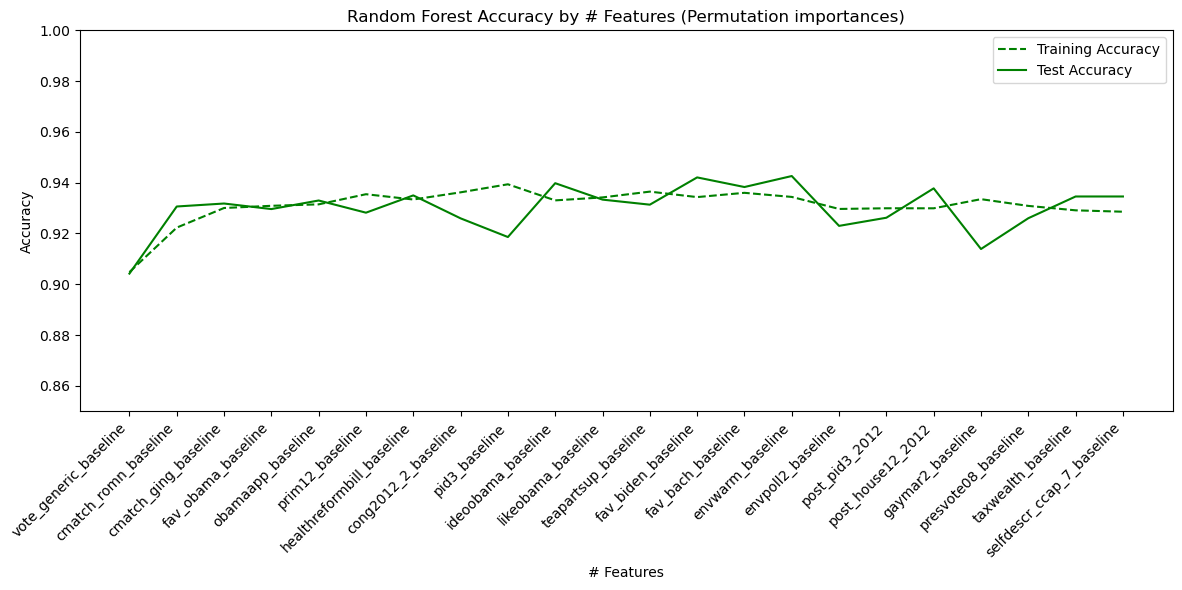

In [59]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 23))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:
    #read inital df each time and drop rows after selecting variables
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA_2012.parquet') 
    featurestokeep = selectedfeatures_perm[0:i].copy() 
    featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'Feature Names': selectedfeatures_perm[:len(featurecount)],  # Get corresponding feature names
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'], label='Training Accuracy', linestyle = '--', color = 'green')
plt.plot(results_df['# Features'], results_df['test_accuracy'], label='Test Accuracy', color = 'green')
plt.ylim(0.85,1.0)
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by # Features (Permutation importances)')
plt.legend()
plt.grid(False)

# Set custom x-tick labels
plt.xticks(ticks=featurecount, labels=results_df['Feature Names'], rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to prevent label cutoff

#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_permutation_maxdepth_2012{selectedmaxdepth}.png')
plt.show()


### fit random forest using the feature selection based on cramers V from the featureselection notebook

In [60]:
selectedfeatures_cramer = pd.read_csv('data/df_top25_cramersv_2012.csv')
selectedfeatures_cramer = selectedfeatures_cramer.columns.tolist()
selectedfeatures_cramer

['post_presvote12_2012',
 'cmatch_romn_baseline',
 'vote_generic_baseline',
 'obamaapp_baseline',
 'healthreformbill_baseline',
 'teapartsup_baseline',
 'post_house12_2012',
 'fav_biden_baseline',
 'healthqualch3_baseline',
 'post_ideo5_2012',
 'govt_reg_baseline',
 'fav_hrc_baseline',
 'post_pid3_2012',
 'healthtaxch3_baseline',
 'fav_bach_baseline',
 'fav_sant_baseline',
 'envwarm_baseline',
 'fav_ging_baseline',
 'fav_perr_baseline',
 'taxwealth_baseline',
 'saysobama_baseline',
 'envser2_baseline',
 'likenewt_baseline',
 'track_baseline',
 'econtrend_baseline',
 'presvote16post_2016']

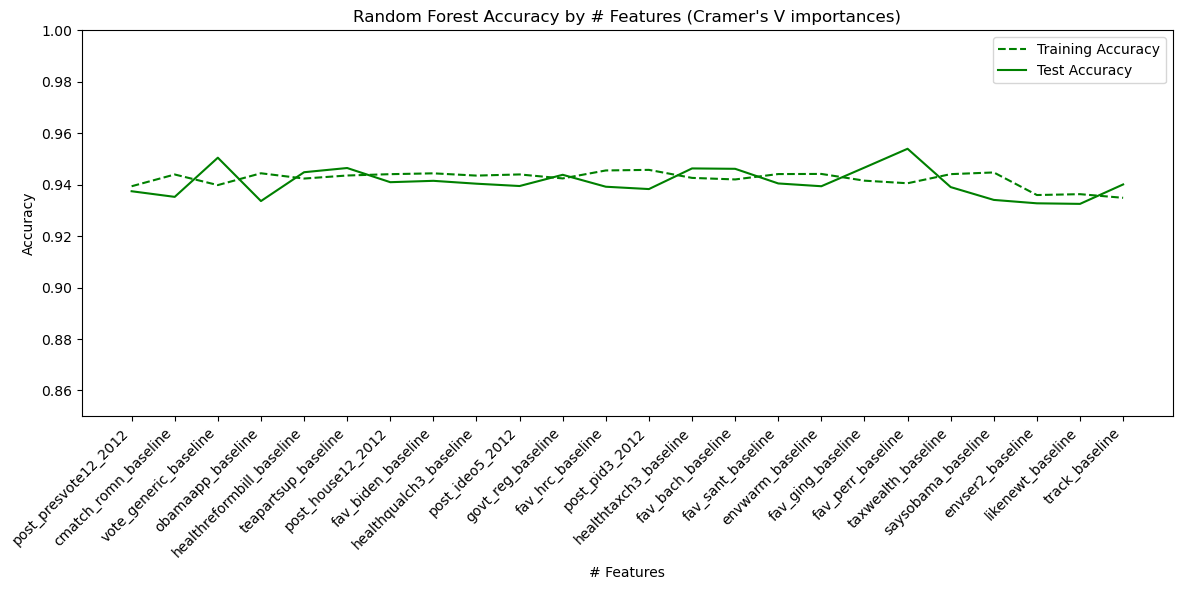

In [63]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 25))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:

    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA_2012.parquet') 
    featurestokeep = selectedfeatures_cramer[0:i].copy() 
    featurestokeep.append('presvote16post_2016') #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
   
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")


    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'Feature Names': selectedfeatures_cramer[:len(featurecount)],  # Get corresponding feature names
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})


# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'], label='Training Accuracy', linestyle = '--', color = 'green')
plt.plot(results_df['# Features'], results_df['test_accuracy'], label='Test Accuracy', color = 'green')
plt.ylim(0.85,1.0)
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by # Features (Cramer\'s V importances)')
plt.legend()
plt.grid(False)

# Set custom x-tick labels
plt.xticks(ticks=featurecount, labels=results_df['Feature Names'], rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to prevent label cutoff

#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_cramersV_maxdepth{selectedmaxdepth}_2012.png')
plt.show()



In [ ]:
#legacy code with the old plot layout
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['# Features'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by # Features (Cramer\'s V importances)')
plt.legend()
plt.grid(True)

# Set custom x-tick labels
plt.xticks(ticks=featurecount, labels=results_df['Feature Names'], rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to prevent label cutoff

#save figure
#plt.savefig(f'results/RF/RF_performance_by_number_of_features_cramersV_maxdepth{selectedmaxdepth}_2012.png')
plt.show()
